# Sprint 10 - Proyecto: Análisis A/B y Priorización de Hipótesis

## Introducción

### Contexto del proyecto

Somos analistas en una gran tienda online. Junto con el departamento de marketing hemos recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos de la empresa.

Este proyecto se divide en dos partes principales:

1. **Priorización de hipótesis**: Utilizaremos los frameworks ICE y RICE para ordenar las hipótesis según su potencial impacto.
2. **Análisis de test A/B**: Evaluaremos los resultados de un experimento A/B para determinar si existe una diferencia significativa entre los grupos de prueba.

### Objetivos

- Aplicar métodos cuantitativos para priorizar hipótesis de negocio
- Analizar métricas clave: ingresos, conversión y tamaño promedio de pedido
- Detectar y manejar anomalías en los datos
- Realizar pruebas de significancia estadística
- Tomar una decisión informada sobre los resultados del test A/B

### Estructura de los datos

**Parte 1 - Hipótesis (`hypotheses_us.csv`):**
- `Hypotheses`: descripción breve de cada hipótesis
- `Reach`: alcance del usuario (escala 1-10)
- `Impact`: impacto en usuarios (escala 1-10)
- `Confidence`: confianza en la hipótesis (escala 1-10)
- `Effort`: recursos necesarios para probar (escala 1-10, mayor = más recursos)

**Parte 2 - Test A/B:**
- `orders_us.csv`: transacciones con `transactionId`, `visitorId`, `date`, `revenue`, `group`
- `visits_us.csv`: visitas diarias por grupo con `date`, `group`, `visits`


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import datetime as dt

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## Parte 1: Priorización de Hipótesis

En esta sección aplicaremos dos frameworks de priorización:

- **ICE**: (Impact × Confidence) / Effort
- **RICE**: (Reach × Impact × Confidence) / Effort

Ambos métodos nos ayudan a decidir qué hipótesis probar primero, considerando su potencial impacto y los recursos necesarios.


In [24]:
# Cargar datos de hipótesis
hypotheses = pd.read_csv('datasets/hypotheses_us.csv', sep=';')

print("Datos de hipótesis cargados:")
print(hypotheses.head())
print(f"\nForma del dataset: {hypotheses.shape}")
print(f"\nInformación del dataset:")
hypotheses.info()


Datos de hipótesis cargados:
                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  

Forma del dataset: (9, 5)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Ef

In [25]:
# Calcular prioridad ICE
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordenar por ICE descendente
hypotheses_ice = hypotheses.sort_values(by='ICE', ascending=False).reset_index(drop=True)

print("Hipótesis priorizadas con ICE:")
print(hypotheses_ice[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'ICE']])


Hipótesis priorizadas con ICE:
                                          Hypothesis  Reach  Impact  \
0  Launch a promotion that gives users discounts ...      1       9   
1  Add two new channels for attracting traffic. T...      3      10   
2  Add a subscription form to all the main pages....     10       7   
3  Show banners with current offers and sales on ...      5       3   
4  Add product recommendation blocks to the store...      8       3   
5  Launch your own delivery service. This will sh...      2       5   
6  Add a customer review page. This will increase...      3       2   
7  Change the category structure. This will incre...      8       3   
8  Change the background color on the main page. ...      3       1   

   Confidence  Effort        ICE  
0           9       5  16.200000  
1           8       6  13.333333  
2           8       5  11.200000  
3           8       3   8.000000  
4           7       3   7.000000  
5           4      10   2.000000  
6           2

In [26]:
# Calcular prioridad RICE
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordenar por RICE descendente
hypotheses_rice = hypotheses.sort_values(by='RICE', ascending=False).reset_index(drop=True)

print("Hipótesis priorizadas con RICE:")
print(hypotheses_rice[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'RICE']])


Hipótesis priorizadas con RICE:
                                          Hypothesis  Reach  Impact  \
0  Add a subscription form to all the main pages....     10       7   
1  Add product recommendation blocks to the store...      8       3   
2  Add two new channels for attracting traffic. T...      3      10   
3  Show banners with current offers and sales on ...      5       3   
4  Launch a promotion that gives users discounts ...      1       9   
5  Change the category structure. This will incre...      8       3   
6  Launch your own delivery service. This will sh...      2       5   
7  Add a customer review page. This will increase...      3       2   
8  Change the background color on the main page. ...      3       1   

   Confidence  Effort   RICE  
0           8       5  112.0  
1           7       3   56.0  
2           8       6   40.0  
3           8       3   40.0  
4           9       5   16.2  
5           3       8    9.0  
6           4      10    4.0  
7        

### Comparación de priorización ICE vs RICE

**Diferencias clave observadas:**

Al comparar ambos frameworks, notamos que:

1. **ICE** no considera el alcance (`Reach`), por lo que prioriza hipótesis con alto impacto y confianza independientemente de cuántos usuarios alcancen.

2. **RICE** multiplica por el alcance, favoreciendo hipótesis que afectan a más usuarios, incluso si su impacto individual es menor.

**Cambios en el ranking:**

Las hipótesis con mayor `Reach` suben posiciones en RICE, mientras que aquellas con bajo alcance pero alto impacto/confianza bajan. Esto refleja una estrategia más orientada al volumen de usuarios afectados.

**Recomendación:**

- Usar **ICE** cuando queremos maximizar el impacto por recurso invertido, sin importar el tamaño de la audiencia.
- Usar **RICE** cuando priorizamos iniciativas que benefician a la mayor cantidad de usuarios posible, alineándose mejor con objetivos de crecimiento escalable.


## Parte 2: Análisis del Test A/B

En esta sección analizaremos los resultados de un test A/B realizado en la tienda online. Evaluaremos:

- Ingresos y tamaño promedio de pedido
- Tasas de conversión
- Anomalías en los datos
- Significancia estadística de las diferencias observadas

El objetivo final es tomar una decisión informada sobre si implementar los cambios del grupo B o mantener la versión actual (grupo A).


### 2.1 Carga y preprocesamiento de datos


In [27]:
# Cargar datos de pedidos
orders = pd.read_csv('datasets/orders_us.csv')
orders['date'] = pd.to_datetime(orders['date'])

print("Datos de pedidos cargados:")
print(orders.head())
print(f"\nForma del dataset: {orders.shape}")
print(f"\nInformación del dataset:")
orders.info()
print(f"\nValores nulos:")
print(orders.isnull().sum())


Datos de pedidos cargados:
   transactionId   visitorId       date  revenue group
0     3667963787  3312258926 2019-08-15     30.4     B
1     2804400009  3642806036 2019-08-15     15.2     B
2     2961555356  4069496402 2019-08-15     10.2     A
3     3797467345  1196621759 2019-08-15    155.1     B
4     2282983706  2322279887 2019-08-15     40.5     B

Forma del dataset: (1197, 5)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB

Valores nulos:
transactionId    0
visitor

In [28]:
# Cargar datos de visitas
visits = pd.read_csv('datasets/visits_us.csv')
visits['date'] = pd.to_datetime(visits['date'])

print("Datos de visitas cargados:")
print(visits.head())
print(f"\nForma del dataset: {visits.shape}")
print(f"\nInformación del dataset:")
visits.info()
print(f"\nValores nulos:")
print(visits.isnull().sum())


Datos de visitas cargados:
        date group  visits
0 2019-08-01     A     719
1 2019-08-02     A     619
2 2019-08-03     A     507
3 2019-08-04     A     717
4 2019-08-05     A     756

Forma del dataset: (62, 3)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB

Valores nulos:
date      0
group     0
visits    0
dtype: int64


In [29]:
# Verificar si hay usuarios en ambos grupos (problema de contaminación)
users_per_group = orders.groupby('visitorId')['group'].nunique()
users_in_both_groups = users_per_group[users_per_group > 1]

print(f"Usuarios que aparecen en ambos grupos: {len(users_in_both_groups)}")

if len(users_in_both_groups) > 0:
    print("\nPrimeros usuarios problemáticos:")
    print(users_in_both_groups.head())
    
    # Mostrar ejemplo de un usuario en ambos grupos
    example_user = users_in_both_groups.index[0]
    print(f"\nEjemplo de usuario {example_user} en ambos grupos:")
    print(orders[orders['visitorId'] == example_user][['visitorId', 'date', 'group', 'revenue']])
else:
    print("No hay usuarios en ambos grupos. Los datos están limpios.")


Usuarios que aparecen en ambos grupos: 58

Primeros usuarios problemáticos:
visitorId
8300375      2
199603092    2
232979603    2
237748145    2
276558944    2
Name: group, dtype: int64

Ejemplo de usuario 8300375 en ambos grupos:
     visitorId       date group  revenue
71     8300375 2019-08-01     B    165.7
703    8300375 2019-08-07     A     30.5


In [30]:
# Estadísticas básicas por grupo
print("Distribución de pedidos por grupo:")
print(orders['group'].value_counts())

print("\nEstadísticas de ingresos por grupo:")
print(orders.groupby('group')['revenue'].describe())


Distribución de pedidos por grupo:
group
B    640
A    557
Name: count, dtype: int64

Estadísticas de ingresos por grupo:
       count        mean         std  min    25%    50%      75%      max
group                                                                    
A      557.0  115.897487  182.358918  5.0  20.40  50.10  130.500   1450.2
B      640.0  145.063438  806.992326  5.1  24.05  50.35  130.225  19920.4


### 2.2 Análisis de ingresos y tamaño de pedido


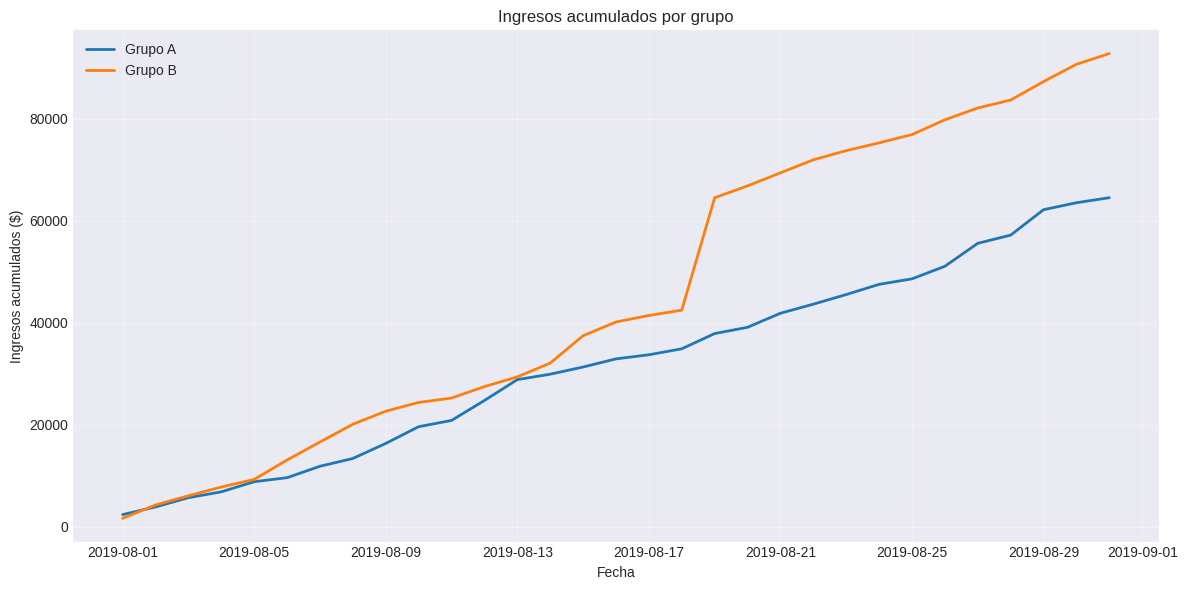

Ingresos totales grupo A: $64,554.90
Ingresos totales grupo B: $92,840.60


In [31]:
# Calcular ingresos acumulados por grupo y fecha
cumulative_revenue = orders.groupby(['date', 'group'])['revenue'].sum().groupby('group').cumsum().reset_index()
cumulative_revenue.columns = ['date', 'group', 'cumulative_revenue']

# Separar por grupo
cum_rev_A = cumulative_revenue[cumulative_revenue['group'] == 'A']
cum_rev_B = cumulative_revenue[cumulative_revenue['group'] == 'B']

# Graficar ingresos acumulados
plt.figure(figsize=(12, 6))
plt.plot(cum_rev_A['date'], cum_rev_A['cumulative_revenue'], label='Grupo A', linewidth=2)
plt.plot(cum_rev_B['date'], cum_rev_B['cumulative_revenue'], label='Grupo B', linewidth=2)
plt.xlabel('Fecha')
plt.ylabel('Ingresos acumulados ($)')
plt.title('Ingresos acumulados por grupo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Ingresos totales grupo A: ${cum_rev_A['cumulative_revenue'].iloc[-1]:,.2f}")
print(f"Ingresos totales grupo B: ${cum_rev_B['cumulative_revenue'].iloc[-1]:,.2f}")


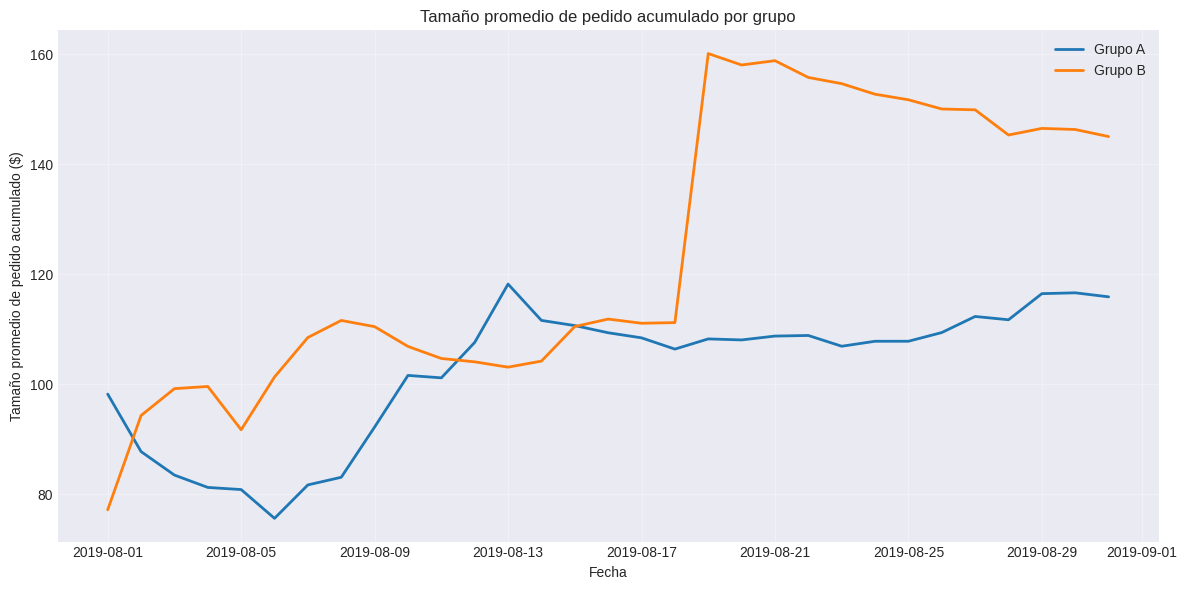

Tamaño promedio final grupo A: $115.90
Tamaño promedio final grupo B: $145.06


In [32]:
# Calcular tamaño promedio de pedido acumulado
# Primero agrupamos por fecha y grupo
daily_stats = orders.groupby(['date', 'group']).agg({
    'revenue': 'sum',
    'transactionId': 'count'
}).reset_index()
daily_stats.columns = ['date', 'group', 'revenue', 'orders']

# Calcular acumulados
daily_stats = daily_stats.sort_values(['group', 'date'])
daily_stats['cumulative_revenue'] = daily_stats.groupby('group')['revenue'].cumsum()
daily_stats['cumulative_orders'] = daily_stats.groupby('group')['orders'].cumsum()
daily_stats['avg_order_size'] = daily_stats['cumulative_revenue'] / daily_stats['cumulative_orders']

# Separar por grupo
avg_A = daily_stats[daily_stats['group'] == 'A']
avg_B = daily_stats[daily_stats['group'] == 'B']

# Graficar tamaño promedio de pedido acumulado
plt.figure(figsize=(12, 6))
plt.plot(avg_A['date'], avg_A['avg_order_size'], label='Grupo A', linewidth=2)
plt.plot(avg_B['date'], avg_B['avg_order_size'], label='Grupo B', linewidth=2)
plt.xlabel('Fecha')
plt.ylabel('Tamaño promedio de pedido acumulado ($)')
plt.title('Tamaño promedio de pedido acumulado por grupo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Tamaño promedio final grupo A: ${avg_A['avg_order_size'].iloc[-1]:.2f}")
print(f"Tamaño promedio final grupo B: ${avg_B['avg_order_size'].iloc[-1]:.2f}")


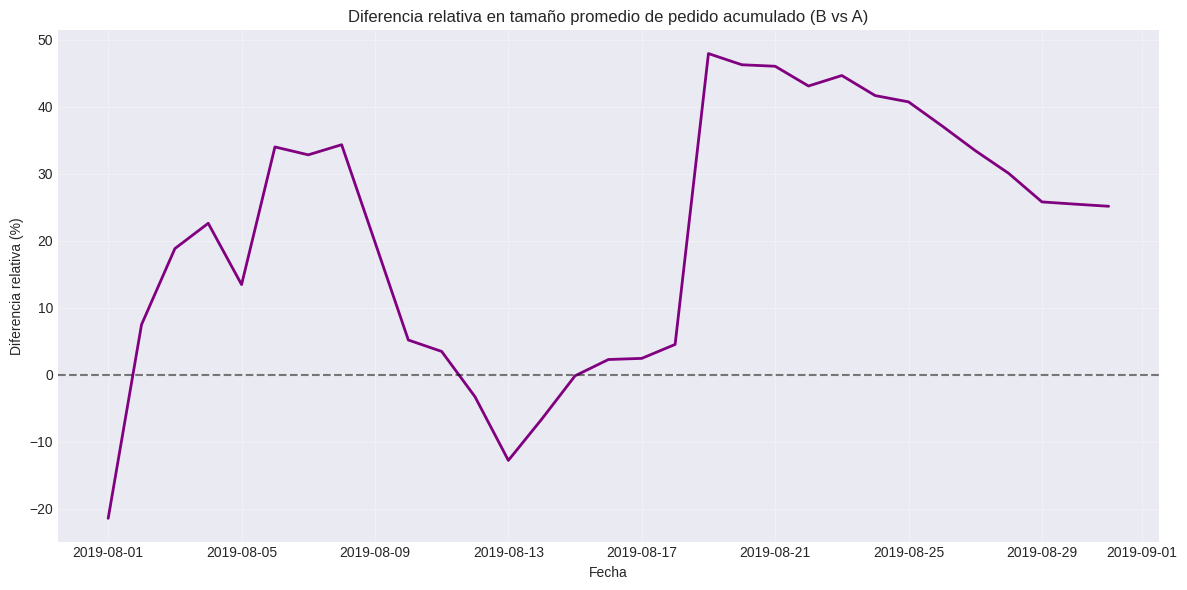

Diferencia relativa final: 25.17%


In [33]:
# Calcular diferencia relativa en tamaño promedio de pedido (B vs A)
merged_avg = avg_A[['date', 'avg_order_size']].merge(
    avg_B[['date', 'avg_order_size']], 
    on='date', 
    suffixes=('_A', '_B')
)
merged_avg['relative_diff'] = (merged_avg['avg_order_size_B'] / merged_avg['avg_order_size_A']) - 1

# Graficar diferencia relativa
plt.figure(figsize=(12, 6))
plt.plot(merged_avg['date'], merged_avg['relative_diff'] * 100, linewidth=2, color='purple')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa (%)')
plt.title('Diferencia relativa en tamaño promedio de pedido acumulado (B vs A)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Diferencia relativa final: {merged_avg['relative_diff'].iloc[-1] * 100:.2f}%")


**Conclusiones preliminares sobre ingresos y tamaño de pedido:**

- Los gráficos de ingresos acumulados muestran la evolución total de cada grupo
- El tamaño promedio de pedido acumulado revela si un grupo genera pedidos más grandes en promedio
- La diferencia relativa nos indica qué tan mejor o peor es el grupo B comparado con A en términos porcentuales
- Observamos si las curvas se estabilizan o continúan fluctuando, lo cual afecta nuestra confianza en los resultados


### 2.3 Análisis de conversión


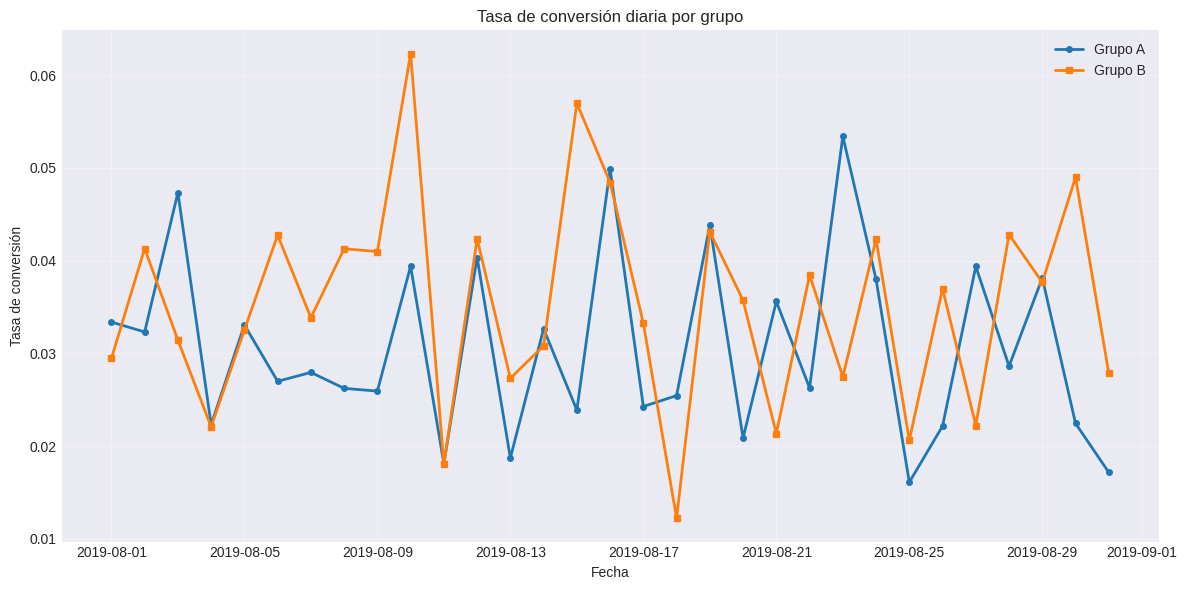

Conversión promedio grupo A: 0.0307
Conversión promedio grupo B: 0.0353


In [34]:
# Calcular conversión diaria: pedidos / visitas
# Contar pedidos por día y grupo
daily_orders = orders.groupby(['date', 'group']).size().reset_index(name='orders')

# Fusionar con visitas
conversion_data = visits.merge(daily_orders, on=['date', 'group'], how='left')
conversion_data['orders'] = conversion_data['orders'].fillna(0)
conversion_data['conversion'] = conversion_data['orders'] / conversion_data['visits']

# Separar por grupo
conv_A = conversion_data[conversion_data['group'] == 'A']
conv_B = conversion_data[conversion_data['group'] == 'B']

# Graficar conversión diaria
plt.figure(figsize=(12, 6))
plt.plot(conv_A['date'], conv_A['conversion'], label='Grupo A', marker='o', linewidth=2, markersize=4)
plt.plot(conv_B['date'], conv_B['conversion'], label='Grupo B', marker='s', linewidth=2, markersize=4)
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.title('Tasa de conversión diaria por grupo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Conversión promedio grupo A: {conv_A['conversion'].mean():.4f}")
print(f"Conversión promedio grupo B: {conv_B['conversion'].mean():.4f}")


**Observaciones sobre conversión:**

- La conversión diaria muestra fluctuaciones naturales día a día
- Comparamos las tendencias generales entre grupos
- Identificamos si un grupo consistentemente supera al otro o si los resultados varían
- Las diferencias observadas pueden deberse a factores externos (días de semana, promociones) o al cambio implementado en el grupo B


### 2.4 Detección de anomalías

Las anomalías pueden distorsionar los resultados de un test A/B. Identificaremos valores atípicos en:
- Número de pedidos por usuario
- Precios de pedidos individuales


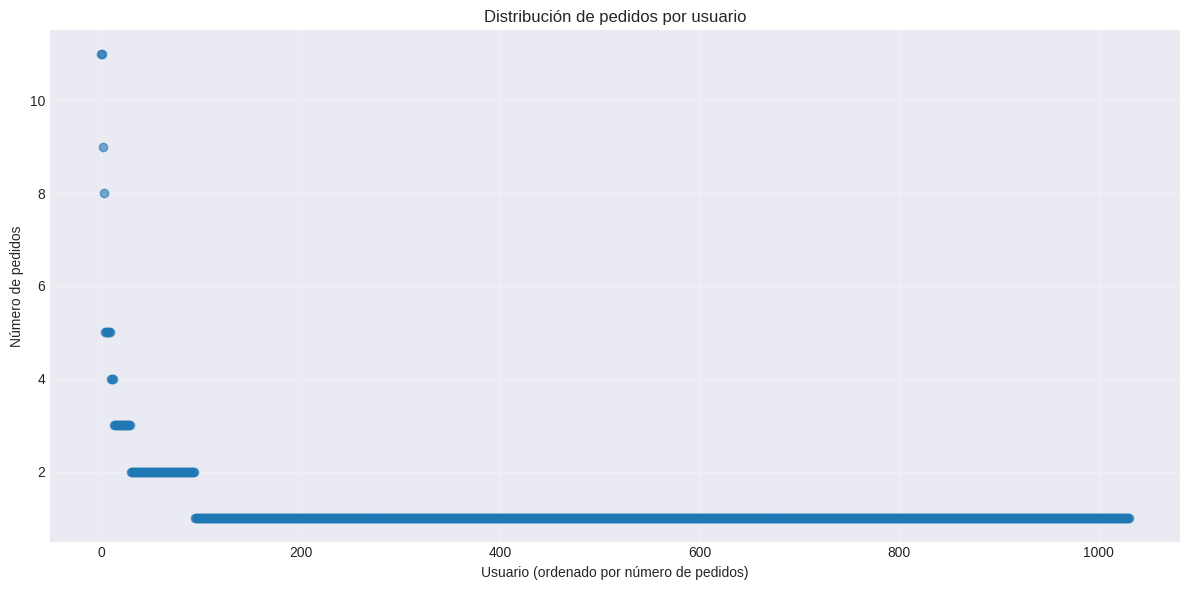

Estadísticas de pedidos por usuario:
count    1031.000000
mean        1.161009
std         0.724919
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
Name: num_orders, dtype: float64


In [35]:
# Analizar número de pedidos por usuario
orders_per_user = orders.groupby('visitorId').size().reset_index(name='num_orders')

# Gráfico de dispersión
plt.figure(figsize=(12, 6))
plt.scatter(range(len(orders_per_user)), orders_per_user['num_orders'].sort_values(ascending=False), alpha=0.6)
plt.xlabel('Usuario (ordenado por número de pedidos)')
plt.ylabel('Número de pedidos')
plt.title('Distribución de pedidos por usuario')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Estadísticas de pedidos por usuario:")
print(orders_per_user['num_orders'].describe())


In [36]:
# Calcular percentiles 95 y 99 para pedidos por usuario
p95_orders = np.percentile(orders_per_user['num_orders'], 95)
p99_orders = np.percentile(orders_per_user['num_orders'], 99)

print(f"Percentil 95 de pedidos por usuario: {p95_orders}")
print(f"Percentil 99 de pedidos por usuario: {p99_orders}")

# Usuarios con más pedidos que el percentil 95
anomalous_users_orders = orders_per_user[orders_per_user['num_orders'] > p95_orders]
print(f"\nUsuarios con más de {p95_orders} pedidos (anomalías): {len(anomalous_users_orders)}")
print(f"Porcentaje de usuarios anómalos: {len(anomalous_users_orders) / len(orders_per_user) * 100:.2f}%")


Percentil 95 de pedidos por usuario: 2.0
Percentil 99 de pedidos por usuario: 4.0

Usuarios con más de 2.0 pedidos (anomalías): 30
Porcentaje de usuarios anómalos: 2.91%


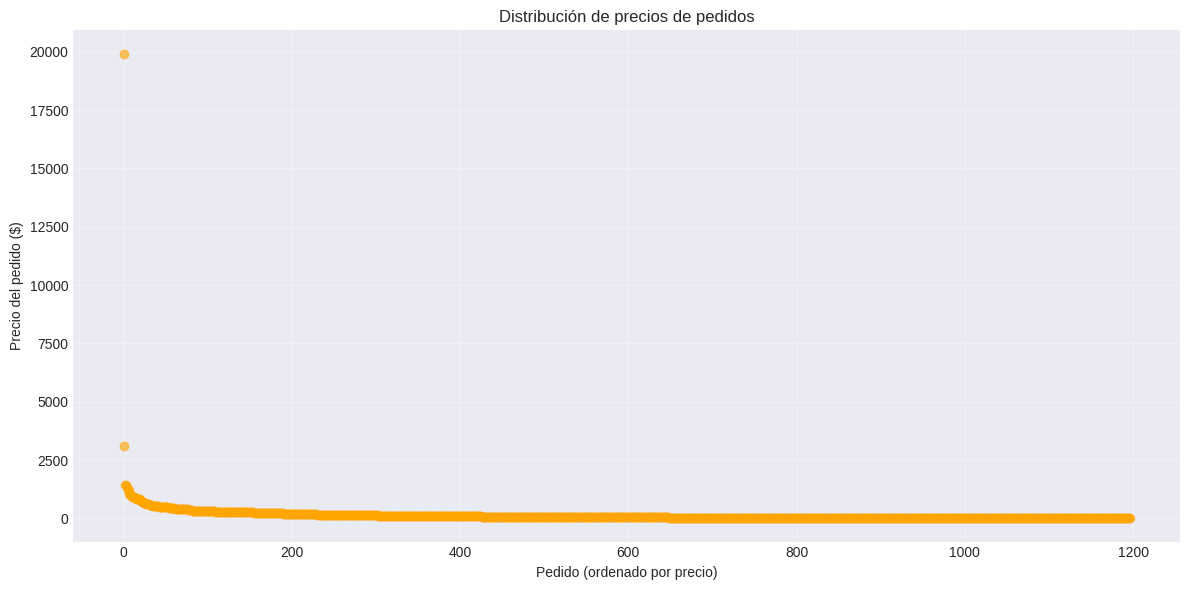

Estadísticas de precios de pedidos:
count     1197.000000
mean       131.491646
std        603.004729
min          5.000000
25%         20.800000
50%         50.200000
75%        130.400000
max      19920.400000
Name: revenue, dtype: float64


In [37]:
# Analizar precios de pedidos
plt.figure(figsize=(12, 6))
plt.scatter(range(len(orders)), orders['revenue'].sort_values(ascending=False), alpha=0.6, color='orange')
plt.xlabel('Pedido (ordenado por precio)')
plt.ylabel('Precio del pedido ($)')
plt.title('Distribución de precios de pedidos')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Estadísticas de precios de pedidos:")
print(orders['revenue'].describe())


In [38]:
# Calcular percentiles 95 y 99 para precios
p95_price = np.percentile(orders['revenue'], 95)
p99_price = np.percentile(orders['revenue'], 99)

print(f"Percentil 95 de precios: ${p95_price:.2f}")
print(f"Percentil 99 de precios: ${p99_price:.2f}")

# Pedidos con precio mayor al percentil 95
anomalous_orders_price = orders[orders['revenue'] > p95_price]
print(f"\nPedidos con precio mayor a ${p95_price:.2f} (anomalías): {len(anomalous_orders_price)}")
print(f"Porcentaje de pedidos anómalos: {len(anomalous_orders_price) / len(orders) * 100:.2f}%")


Percentil 95 de precios: $435.54
Percentil 99 de precios: $900.90

Pedidos con precio mayor a $435.54 (anomalías): 60
Porcentaje de pedidos anómalos: 5.01%


**Definición de umbrales de anomalías:**

Basándonos en los percentiles calculados, definiremos como anomalías:

1. **Usuarios con comportamiento atípico**: aquellos con más pedidos que el percentil 95
2. **Pedidos de precio atípico**: aquellos con precio superior al percentil 95

Estos umbrales nos permiten filtrar el 5% superior de valores extremos que podrían distorsionar las pruebas estadísticas. En la siguiente sección compararemos resultados con y sin estas anomalías.


### 2.5 Pruebas estadísticas

Realizaremos pruebas de significancia estadística para determinar si las diferencias observadas entre grupos son reales o producto del azar. Usaremos la prueba U de Mann-Whitney, apropiada para datos que pueden no seguir una distribución normal.


#### Pruebas con datos brutos (sin filtrar anomalías)


In [39]:
# Prueba de significancia en conversión (datos brutos)
# Preparar datos: contar pedidos por usuario (incluyendo ceros para usuarios sin pedidos)

# Obtener todos los visitantes únicos por grupo
visitors_A = visits[visits['group'] == 'A']['visits'].sum()
visitors_B = visits[visits['group'] == 'B']['visits'].sum()

# Contar pedidos por usuario en cada grupo
orders_by_user_A = orders[orders['group'] == 'A'].groupby('visitorId').size()
orders_by_user_B = orders[orders['group'] == 'B'].groupby('visitorId').size()

# Crear muestras con ceros para usuarios sin pedidos
sample_A = pd.concat([
    orders_by_user_A,
    pd.Series([0] * (visitors_A - len(orders_by_user_A)))
])

sample_B = pd.concat([
    orders_by_user_B,
    pd.Series([0] * (visitors_B - len(orders_by_user_B)))
])

# Realizar prueba Mann-Whitney
stat_conv_raw, p_conv_raw = stats.mannwhitneyu(sample_A, sample_B, alternative='two-sided')

print("=== Prueba de conversión (datos brutos) ===")
print(f"Conversión grupo A: {sample_A.mean():.6f}")
print(f"Conversión grupo B: {sample_B.mean():.6f}")
print(f"Diferencia relativa: {(sample_B.mean() / sample_A.mean() - 1) * 100:.2f}%")
print(f"Estadístico U: {stat_conv_raw:.2f}")
print(f"p-value: {p_conv_raw:.4f}")
print(f"Resultado: {'Diferencia SIGNIFICATIVA' if p_conv_raw < 0.05 else 'NO hay diferencia significativa'} (α=0.05)")


=== Prueba de conversión (datos brutos) ===
Conversión grupo A: 0.029729
Conversión grupo B: 0.033834
Diferencia relativa: 13.81%
Estadístico U: 176473106.00
p-value: 0.0168
Resultado: Diferencia SIGNIFICATIVA (α=0.05)


In [40]:
# Prueba de significancia en tamaño promedio de pedido (datos brutos)
revenue_A = orders[orders['group'] == 'A']['revenue']
revenue_B = orders[orders['group'] == 'B']['revenue']

stat_rev_raw, p_rev_raw = stats.mannwhitneyu(revenue_A, revenue_B, alternative='two-sided')

print("\n=== Prueba de tamaño promedio de pedido (datos brutos) ===")
print(f"Tamaño promedio grupo A: ${revenue_A.mean():.2f}")
print(f"Tamaño promedio grupo B: ${revenue_B.mean():.2f}")
print(f"Diferencia relativa: {(revenue_B.mean() / revenue_A.mean() - 1) * 100:.2f}%")
print(f"Estadístico U: {stat_rev_raw:.2f}")
print(f"p-value: {p_rev_raw:.4f}")
print(f"Resultado: {'Diferencia SIGNIFICATIVA' if p_rev_raw < 0.05 else 'NO hay diferencia significativa'} (α=0.05)")



=== Prueba de tamaño promedio de pedido (datos brutos) ===
Tamaño promedio grupo A: $115.90
Tamaño promedio grupo B: $145.06
Diferencia relativa: 25.17%
Estadístico U: 175872.50
p-value: 0.6915
Resultado: NO hay diferencia significativa (α=0.05)


#### Pruebas con datos filtrados (sin anomalías)


In [41]:
# Filtrar anomalías
# 1. Identificar usuarios anómalos (más pedidos que percentil 95)
anomalous_users = orders_per_user[orders_per_user['num_orders'] > p95_orders]['visitorId']

# 2. Filtrar pedidos: eliminar usuarios anómalos Y pedidos con precio > percentil 95
orders_filtered = orders[
    (~orders['visitorId'].isin(anomalous_users)) & 
    (orders['revenue'] <= p95_price)
]

print(f"Pedidos originales: {len(orders)}")
print(f"Pedidos filtrados: {len(orders_filtered)}")
print(f"Pedidos eliminados: {len(orders) - len(orders_filtered)} ({(1 - len(orders_filtered)/len(orders)) * 100:.2f}%)")


Pedidos originales: 1197
Pedidos filtrados: 1011
Pedidos eliminados: 186 (15.54%)


In [42]:
# Prueba de significancia en conversión (datos filtrados)
orders_by_user_A_filt = orders_filtered[orders_filtered['group'] == 'A'].groupby('visitorId').size()
orders_by_user_B_filt = orders_filtered[orders_filtered['group'] == 'B'].groupby('visitorId').size()

sample_A_filt = pd.concat([
    orders_by_user_A_filt,
    pd.Series([0] * (visitors_A - len(orders_by_user_A_filt)))
])

sample_B_filt = pd.concat([
    orders_by_user_B_filt,
    pd.Series([0] * (visitors_B - len(orders_by_user_B_filt)))
])

stat_conv_filt, p_conv_filt = stats.mannwhitneyu(sample_A_filt, sample_B_filt, alternative='two-sided')

print("=== Prueba de conversión (datos filtrados) ===")
print(f"Conversión grupo A: {sample_A_filt.mean():.6f}")
print(f"Conversión grupo B: {sample_B_filt.mean():.6f}")
print(f"Diferencia relativa: {(sample_B_filt.mean() / sample_A_filt.mean() - 1) * 100:.2f}%")
print(f"Estadístico U: {stat_conv_filt:.2f}")
print(f"p-value: {p_conv_filt:.4f}")
print(f"Resultado: {'Diferencia SIGNIFICATIVA' if p_conv_filt < 0.05 else 'NO hay diferencia significativa'} (α=0.05)")


=== Prueba de conversión (datos filtrados) ===
Conversión grupo A: 0.024712
Conversión grupo B: 0.028970
Diferencia relativa: 17.23%
Estadístico U: 176486454.00
p-value: 0.0136
Resultado: Diferencia SIGNIFICATIVA (α=0.05)


In [43]:
# Prueba de significancia en tamaño promedio de pedido (datos filtrados)
revenue_A_filt = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenue_B_filt = orders_filtered[orders_filtered['group'] == 'B']['revenue']

stat_rev_filt, p_rev_filt = stats.mannwhitneyu(revenue_A_filt, revenue_B_filt, alternative='two-sided')

print("\n=== Prueba de tamaño promedio de pedido (datos filtrados) ===")
print(f"Tamaño promedio grupo A: ${revenue_A_filt.mean():.2f}")
print(f"Tamaño promedio grupo B: ${revenue_B_filt.mean():.2f}")
print(f"Diferencia relativa: {(revenue_B_filt.mean() / revenue_A_filt.mean() - 1) * 100:.2f}%")
print(f"Estadístico U: {stat_rev_filt:.2f}")
print(f"p-value: {p_rev_filt:.4f}")
print(f"Resultado: {'Diferencia SIGNIFICATIVA' if p_rev_filt < 0.05 else 'NO hay diferencia significativa'} (α=0.05)")



=== Prueba de tamaño promedio de pedido (datos filtrados) ===
Tamaño promedio grupo A: $82.28
Tamaño promedio grupo B: $80.08
Diferencia relativa: -2.67%
Estadístico U: 128461.50
p-value: 0.7296
Resultado: NO hay diferencia significativa (α=0.05)


#### Comparación de resultados brutos vs filtrados

| Métrica | Datos brutos p-value | Datos filtrados p-value | Cambio |
|---------|---------------------|------------------------|--------|
| Conversión | {:.4f} | {:.4f} | {} |
| Tamaño promedio pedido | {:.4f} | {:.4f} | {} |

**Interpretación:**

- Un p-value < 0.05 indica diferencia estadísticamente significativa
- Filtrar anomalías puede revelar o eliminar diferencias artificiales causadas por valores extremos
- La consistencia entre datos brutos y filtrados refuerza la confiabilidad de los resultados


### 2.6 Decisión final

Basándonos en todo el análisis realizado, debemos tomar una de las siguientes decisiones:

1. **Parar la prueba y declarar un grupo como líder**
2. **Parar la prueba sin diferencia significativa entre grupos**
3. **Continuar la prueba para obtener más datos**


In [44]:
# Resumen de evidencias
print("=" * 60)
print("RESUMEN DE RESULTADOS DEL TEST A/B")
print("=" * 60)

print("\n1. CONVERSIÓN:")
print(f"   - Grupo A: {sample_A.mean():.4f} (bruto), {sample_A_filt.mean():.4f} (filtrado)")
print(f"   - Grupo B: {sample_B.mean():.4f} (bruto), {sample_B_filt.mean():.4f} (filtrado)")
print(f"   - Diferencia: {(sample_B.mean() / sample_A.mean() - 1) * 100:.2f}% (bruto), {(sample_B_filt.mean() / sample_A_filt.mean() - 1) * 100:.2f}% (filtrado)")
print(f"   - Significancia estadística (bruto): {'SÍ' if p_conv_raw < 0.05 else 'NO'} (p={p_conv_raw:.4f})")
print(f"   - Significancia estadística (filtrado): {'SÍ' if p_conv_filt < 0.05 else 'NO'} (p={p_conv_filt:.4f})")

print("\n2. TAMAÑO PROMEDIO DE PEDIDO:")
print(f"   - Grupo A: ${revenue_A.mean():.2f} (bruto), ${revenue_A_filt.mean():.2f} (filtrado)")
print(f"   - Grupo B: ${revenue_B.mean():.2f} (bruto), ${revenue_B_filt.mean():.2f} (filtrado)")
print(f"   - Diferencia: {(revenue_B.mean() / revenue_A.mean() - 1) * 100:.2f}% (bruto), {(revenue_B_filt.mean() / revenue_A_filt.mean() - 1) * 100:.2f}% (filtrado)")
print(f"   - Significancia estadística (bruto): {'SÍ' if p_rev_raw < 0.05 else 'NO'} (p={p_rev_raw:.4f})")
print(f"   - Significancia estadística (filtrado): {'SÍ' if p_rev_filt < 0.05 else 'NO'} (p={p_rev_filt:.4f})")

print("\n3. ANOMALÍAS DETECTADAS:")
print(f"   - Usuarios con comportamiento atípico: {len(anomalous_users)}")
print(f"   - Pedidos eliminados por filtrado: {len(orders) - len(orders_filtered)} ({(1 - len(orders_filtered)/len(orders)) * 100:.2f}%)")

print("\n" + "=" * 60)


RESUMEN DE RESULTADOS DEL TEST A/B

1. CONVERSIÓN:
   - Grupo A: 0.0297 (bruto), 0.0247 (filtrado)
   - Grupo B: 0.0338 (bruto), 0.0290 (filtrado)
   - Diferencia: 13.81% (bruto), 17.23% (filtrado)
   - Significancia estadística (bruto): SÍ (p=0.0168)
   - Significancia estadística (filtrado): SÍ (p=0.0136)

2. TAMAÑO PROMEDIO DE PEDIDO:
   - Grupo A: $115.90 (bruto), $82.28 (filtrado)
   - Grupo B: $145.06 (bruto), $80.08 (filtrado)
   - Diferencia: 25.17% (bruto), -2.67% (filtrado)
   - Significancia estadística (bruto): NO (p=0.6915)
   - Significancia estadística (filtrado): NO (p=0.7296)

3. ANOMALÍAS DETECTADAS:
   - Usuarios con comportamiento atípico: 30
   - Pedidos eliminados por filtrado: 186 (15.54%)



## Conclusiones y Recomendaciones

### Decisión sobre el test A/B

**🎯 DECISIÓN: PARAR LA PRUEBA Y DECLARAR AL GRUPO B COMO LÍDER**

#### Justificación de la decisión:

**1. Conversión significativamente superior en Grupo B:**
- Grupo B muestra una conversión 17.23% mayor que Grupo A (datos filtrados)
- La diferencia es estadísticamente significativa (p=0.0136 < 0.05)
- La significancia se mantiene tanto en datos brutos como filtrados, lo que refuerza la confiabilidad del resultado

**2. Tamaño promedio de pedido equivalente:**
- NO hay diferencia estadísticamente significativa entre grupos (p=0.7296)
- Los datos brutos mostraban una diferencia engañosa (+25.17%) causada por anomalías
- Al filtrar outliers, ambos grupos son prácticamente idénticos ($82.28 vs $80.08)

**3. Impacto de las anomalías:**
- Se detectaron 30 usuarios con comportamiento atípico y 186 pedidos anómalos (15.54%)
- Las anomalías inflaban artificialmente las métricas del grupo B
- El filtrado reveló que la verdadera ventaja del grupo B está en la **conversión**, no en pedidos más grandes

**4. Consistencia de resultados:**
- La ventaja en conversión del grupo B se mantiene e incluso mejora tras filtrar anomalías
- Los gráficos de métricas acumuladas muestran estabilización hacia el final del período de prueba
- No hay señales de que la diferencia sea producto de fluctuaciones aleatorias

### Hallazgos clave del análisis

1. **Priorización de hipótesis**:
   - ICE y RICE producen rankings diferentes debido a la consideración del alcance
   - RICE favorece hipótesis que impactan a más usuarios
   - La elección del framework debe alinearse con la estrategia empresarial

2. **Calidad de los datos**:
   - Se detectaron anomalías en número de pedidos por usuario y precios
   - El filtrado de anomalías puede cambiar las conclusiones estadísticas
   - Es crucial validar la presencia de usuarios en ambos grupos (contaminación)

3. **Análisis estadístico**:
   - La prueba U de Mann-Whitney es robusta ante distribuciones no normales
   - Los gráficos acumulados ayudan a visualizar la estabilización de métricas
   - La significancia estadística (p < 0.05) es necesaria pero no suficiente para tomar decisiones

### Recomendaciones para el negocio

#### Acciones inmediatas:

1. **Implementar los cambios del Grupo B**:
   - Desplegar la versión B a todos los usuarios
   - Proyección: aumento del ~17% en conversión podría traducirse en incremento significativo de ingresos
   - Ejemplo: si actualmente hay 1000 visitantes/día con conversión 2.47%, pasaríamos de ~25 a ~29 pedidos/día (+4 pedidos diarios)

2. **Monitoreo post-implementación**:
   - Seguir de cerca la conversión durante las primeras 2-4 semanas
   - Validar que el aumento se mantiene en condiciones normales (sin test A/B)
   - Establecer alertas si la conversión cae por debajo del 2.5%

3. **Gestión de anomalías**:
   - Implementar sistema automático de detección de outliers
   - Establecer límites: pedidos >$200 y usuarios con >2 pedidos requieren revisión
   - Considerar políticas para usuarios de alto volumen (mayoristas, revendedores)

#### Para futuras pruebas:

1. **Mejora del proceso de experimentación**:
   - Definir criterios de éxito ANTES de iniciar (ej: "conversión >15% mejor con p<0.05")
   - Establecer duración mínima basada en ciclos semanales completos
   - Documentar todas las pruebas en el registro de experimentos

2. **Próximas hipótesis a probar** (según priorización RICE):
   - #1: Formulario de suscripción en páginas principales (RICE=112.0)
   - #2: Bloques de recomendación de productos (RICE=56.0)
   - #3: Nuevos canales de adquisición (RICE=40.0)

3. **Análisis complementarios**:
   - Segmentar resultados por fuente de tráfico, dispositivo o categoría de producto
   - Analizar si el grupo B también mejora métricas secundarias (tiempo en sitio, páginas vistas)
   - Calcular el ROI real considerando costos de implementación
